# OKAFF d=1 ARL–EDD comparison — short (8 scenarios)

## Imports

In [1]:
import math
import textwrap
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, LogLocator, NullFormatter


In [2]:
N_RUNS = 200
if N_RUNS <= 0:
    raise ValueError("N_RUNS must be a positive integer")


NOTEBOOK_DIR = Path.cwd().resolve()
EDD_RESULTS_DIR = next(
    (
        root / "EDD" / "d1" / "results"
        for root in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
        if (root / "EDD" / "d1" / "results").is_dir()
    ),
    NOTEBOOK_DIR / "results",
)

## Input sources

In [3]:
@dataclass(frozen=True)
class SourceConfig:
    path: str
    group: str


SOURCES = [
    SourceConfig(EDD_RESULTS_DIR / f"OKAFF-ARL-EDD-d1-nrun{N_RUNS}.csv", "OKAFF"),
    SourceConfig(EDD_RESULTS_DIR / f"NEWMA-EDD-d1-nrun{N_RUNS}.csv", "NEWMA"),
    SourceConfig(EDD_RESULTS_DIR / f"online_rff_mmd-EDD-d1-nrun{N_RUNS}.csv", "Online RFF MMD"),
    SourceConfig(EDD_RESULTS_DIR / f"Scanb-EDD-d1-nrun{N_RUNS}.csv", "ScanB"),
    SourceConfig(EDD_RESULTS_DIR / f"okcusum-EDD-d1-nrun{N_RUNS}.csv", "OK-CUSUM"),
]


## Plot settings

In [4]:
COLUMN_ALIASES = {
    "data": ["post_change_name", "scenario", "data_name", "data"],
    "ARL_hat": ["arl_hat", "ARL_hat"],
    "EDD": ["edd_hat", "EDD_hat", "EDD"],
    "censor_rate": [
        "edd_censored_rate", "edd_censor_rate", "EDD_censor_rate", "censor_rate",
    ],
    "tuning": ["threshold", "chart_L", "tuning", "tau", "alpha", "lambda", "kappa", "L", "k"],
}

DATA_ORDER = [
    "MeanShift(mu=2)",
    "MeanShift(mu=3)",
    "CovDiag(var=0.5)",
    "CovDiag(var=6)",
    "MixedNormal0.1",
    "MixedNormal0.4",
    "Uniform(scale=1.0)",
    "Laplace(scale=3.0)",
]

TITLE_MAP = {
    "MeanShift(mu=2)": r"$\mathcal{N}(2,1)$",
    "MeanShift(mu=3)": r"$\mathcal{N}(3,1)$",
    "CovDiag(var=0.5)": r"$\mathcal{N}(0,0.5)$",
    "CovDiag(var=6)": r"$\mathcal{N}(0,6)$",
    "MixedNormal0.1": r"$\mathrm{MixedNormal}(0.1)$",
    "MixedNormal0.4": r"$\mathrm{MixedNormal}(0.4)$",
    "Uniform(scale=1.0)": r"$\operatorname{Uniform}([-1,1])$",
    "Laplace(scale=3.0)": r"$\operatorname{Laplace}(0,3)$",
}

GROUPS = ["OKAFF", "NEWMA", "Online RFF MMD", "ScanB", "OK-CUSUM"]

COLOR_MAP = {
    "OKAFF": "tab:orange",
    "NEWMA": "tab:green",
    "Online RFF MMD": "tab:purple",
    "ScanB": "tab:brown",
    "OK-CUSUM": "tab:pink",
}

MARKER_MAP = {
    "OKAFF": "s",
    "NEWMA": "^",
    "Online RFF MMD": "v",
    "ScanB": "p",
    "OK-CUSUM": "*",
}

CENSOR_CROSS_RATE = 0.40
Y_TOP_PADDING_FACTOR = 1.50


## Load and standardize results

In [5]:
def first_existing_column(df, candidates):
    return next((col for col in candidates if col in df.columns), None)


def standardize_source(source):
    path = Path(source.path)
    if not path.exists():
        print(f"Warning: {source.path} not found. Skipping {source.group}.")
        return None

    df = pd.read_csv(path)
    rename_map = {}

    for target, aliases in COLUMN_ALIASES.items():
        col = first_existing_column(df, aliases)
        if col is not None and col != target:
            rename_map[col] = target

    df = df.rename(columns=rename_map)

    required = {"data", "ARL_hat", "EDD"}
    missing = sorted(required - set(df.columns))
    if missing:
        print(f"Warning: {path.name} missing {missing}. Skipping {source.group}.")
        return None

    if "censor_rate" not in df.columns:
        df["censor_rate"] = 0.0
    if "tuning" not in df.columns:
        df["tuning"] = np.nan

    df["data"] = df["data"].astype(str).str.strip()
    df["Group"] = source.group
    return df


def load_results(sources=SOURCES):
    frames = []
    for source in sources:
        df = standardize_source(source)
        if df is not None:
            frames.append(df)

    if not frames:
        raise FileNotFoundError("No usable CSV files were found.")

    df = pd.concat(frames, ignore_index=True, sort=False)
    df.columns = df.columns.str.strip()

    df["Group"] = df["Group"].astype(str).str.strip()
    for col in ["ARL_hat", "EDD", "censor_rate"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["data", "Group", "ARL_hat", "EDD"])
    df = df[(df["ARL_hat"] > 0) & (df["EDD"] > 0)]
    return df.copy()


## Names and output files

In [6]:
def wrap_title(s, width=28):
    return "\n".join(textwrap.wrap(str(s), width=width))


def postchange_row_name(row_datas, row_idx):
    """Return the filename for each row in the short comparison."""
    if row_datas and all(name.startswith(("MeanShift(", "CovDiag(")) for name in row_datas):
        return "edd_vs_arl_mean_variance_shifts_d1.pdf"
    if row_datas and all(
        name.startswith(("MixedNormal", "Uniform(", "Laplace("))
        for name in row_datas
    ):
        return "edd_vs_arl_mixture_uniform_laplace_d1.pdf"
    return f"edd_vs_arl_row{row_idx:02d}_d1_short.pdf"


## Draw panels

In [7]:
def plot_panel(ax, df, dname, y_limits, legend_handles, show_ylabel=False):
    sub_all = df[df["data"] == dname]

    for group in GROUPS:
        sub = sub_all[sub_all["Group"] == group].sort_values("ARL_hat")
        if sub.empty:
            continue

        low = sub["censor_rate"].fillna(0) < CENSOR_CROSS_RATE
        if low.any():
            line, = ax.plot(
                sub.loc[low, "ARL_hat"],
                sub.loc[low, "EDD"],
                marker=MARKER_MAP[group],
                color=COLOR_MAP[group],
                linewidth=1.5,
                markersize=4,
                label=group,
            )
            legend_handles.setdefault(group, line)

        if (~low).any():
            ax.plot(
                sub.loc[~low, "ARL_hat"],
                sub.loc[~low, "EDD"],
                linestyle="None",
                marker="x",
                color=COLOR_MAP[group],
                markersize=6,
                markeredgewidth=1.2,
            )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(*y_limits)

    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())

    title = TITLE_MAP.get(dname, wrap_title(dname))
    ax.set_title(title, fontsize=9, pad=10)
    ax.set_xlabel(r"$\mathrm{ARL}$", fontsize=10)
    if show_ylabel:
        ax.set_ylabel("EDD", fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)


## Save figure rows

In [8]:
def save_row_plots(df, output_dir="row_pdfs", ncols=4, include_unlisted=False):
    present = set(df["data"].unique())
    datas = [name for name in DATA_ORDER if name in present]
    if include_unlisted:
        datas.extend(sorted(present - set(datas)))

    if not datas:
        raise ValueError("No scenarios matched DATA_ORDER.")

    positive_edd = df.loc[df["EDD"] > 0, "EDD"]
    y_limits = (
        10 ** math.floor(math.log10(positive_edd.min())),
        (10 ** math.ceil(math.log10(positive_edd.max()))) * Y_TOP_PADDING_FACTOR,
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    saved_paths = []
    for row_idx, start in enumerate(range(0, len(datas), ncols), start=1):
        row_datas = datas[start:start + ncols]
        fig, axes = plt.subplots(1, ncols, figsize=(4.0 * ncols, 3.8), squeeze=False)
        axes = axes.ravel()
        legend_handles = {}

        for col_idx, ax in enumerate(axes):
            if col_idx < len(row_datas):
                plot_panel(
                    ax,
                    df,
                    row_datas[col_idx],
                    y_limits,
                    legend_handles,
                    show_ylabel=(col_idx == 0),
                )
            else:
                ax.axis("off")

        legend_groups = [g for g in GROUPS if g in legend_handles]
        if legend_groups:
            fig.legend(
                [legend_handles[g] for g in legend_groups],
                legend_groups,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.98),
                ncol=len(legend_groups),
                frameon=False,
                fontsize=10,
            )

        fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.88])

        out_path = output_dir / postchange_row_name(row_datas, row_idx)
        fig.savefig(out_path, bbox_inches="tight")
        saved_paths.append(out_path)

        plt.show()
        plt.close(fig)

    return saved_paths


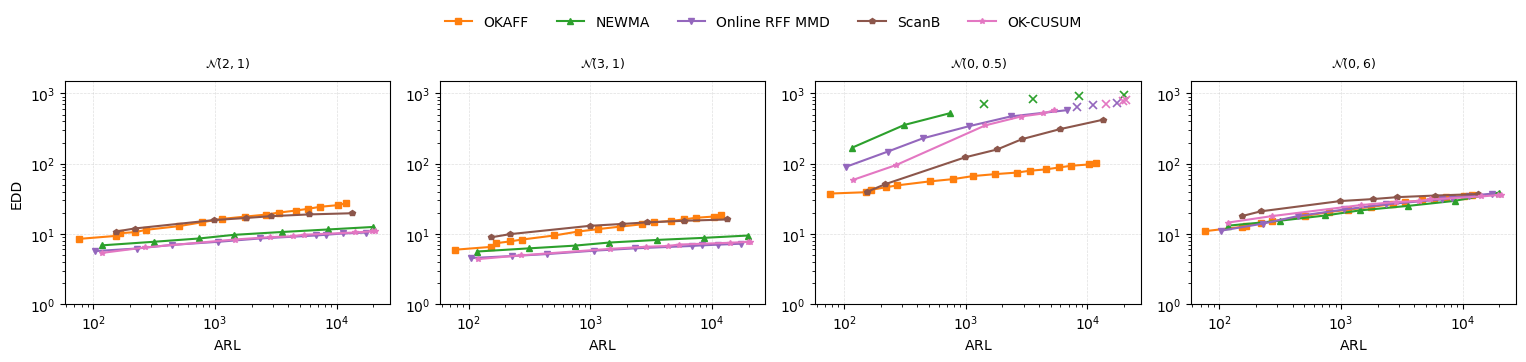

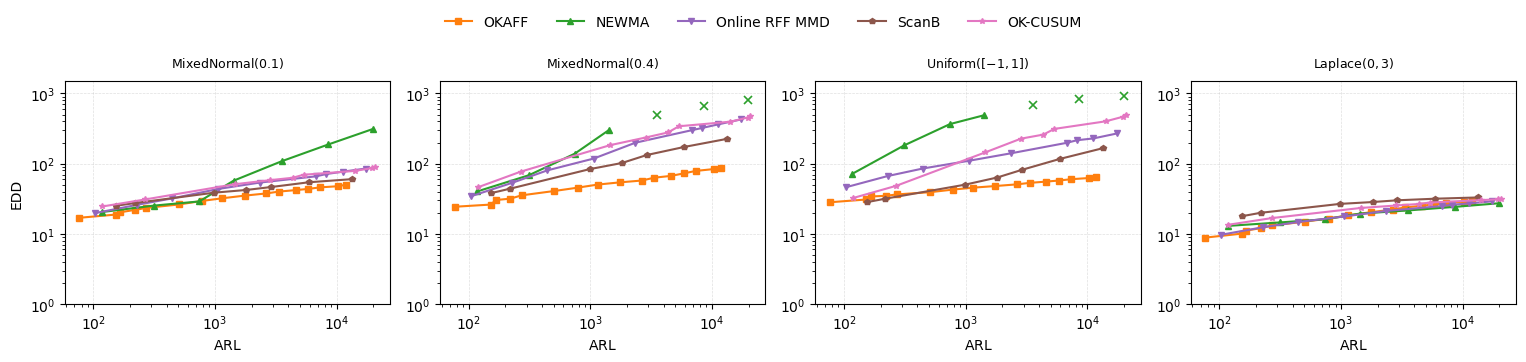

Loaded 1,872 rows across 5 group(s).
Saved row PDFs:
arl_edd_d1_short/edd_vs_arl_mean_variance_shifts_d1.pdf
arl_edd_d1_short/edd_vs_arl_mixture_uniform_laplace_d1.pdf


In [9]:
dfp = load_results()
saved_paths = save_row_plots(dfp, output_dir="arl_edd_d1_short")

print(f"Loaded {len(dfp):,} rows across {dfp['Group'].nunique()} group(s).")
print("Saved row PDFs:")
for path in saved_paths:
    print(path)
